In [1]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('/content/train_data_merged_cleaned.csv', encoding='utf-8')
df_test = pd.read_csv('/content/test_data_merged_cleaned.csv', encoding='utf-8')

df_train['Success/Failure'] = np.where(df_train['dd10 CM Content'] >= 70, 1, 0)
df_test['Success/Failure'] = np.where(df_test['dd10 CM Content'] >= 70, 1, 0)

# Glucose Gradient 파생 변수 생성
df_train['dd0-dd1 Glucose Gradient'] = (df_train['dd1 Glucose Concentration']- df_train['dd0 Glucose Concentration'])
df_train['dd1-dd3 Glucose Gradient'] = (df_train['dd3 Glucose Concentration']- df_train['dd1 Glucose Concentration'])
df_train['dd3-dd5 Glucose Gradient'] = (df_train['dd5 Glucose Concentration']- df_train['dd3 Glucose Concentration'])
df_train['dd5-dd7 Glucose Gradient'] = (df_train['dd7 Glucose Concentration']- df_train['dd5 Glucose Concentration'])
df_test['dd0-dd1 Glucose Gradient'] = (df_test['dd1 Glucose Concentration']- df_test['dd0 Glucose Concentration'])
df_test['dd1-dd3 Glucose Gradient'] = (df_test['dd3 Glucose Concentration']- df_test['dd1 Glucose Concentration'])
df_test['dd3-dd5 Glucose Gradient'] = (df_test['dd5 Glucose Concentration']- df_test['dd3 Glucose Concentration'])
df_test['dd5-dd7 Glucose Gradient'] = (df_test['dd7 Glucose Concentration']- df_test['dd5 Glucose Concentration'])

# Lactate Gradient 파생 변수 생성
df_train['dd0-dd1 Lactate Gradient'] = (df_train['dd1 Lactate Concentration']- df_train['dd0 Lactate Concentration'])
df_train['dd1-dd3 Lactate Gradient'] = (df_train['dd3 Lactate Concentration']- df_train['dd1 Lactate Concentration'])
df_train['dd3-dd5 Lactate Gradient'] = (df_train['dd5 Lactate Concentration']- df_train['dd3 Lactate Concentration'])
df_train['dd5-dd7 Lactate Gradient'] = (df_train['dd7 Lactate Concentration']- df_train['dd5 Lactate Concentration'])
df_test['dd0-dd1 Lactate Gradient'] = (df_test['dd1 Lactate Concentration']- df_test['dd0 Lactate Concentration'])
df_test['dd1-dd3 Lactate Gradient'] = (df_test['dd3 Lactate Concentration']- df_test['dd1 Lactate Concentration'])
df_test['dd3-dd5 Lactate Gradient'] = (df_test['dd5 Lactate Concentration']- df_test['dd3 Lactate Concentration'])
df_test['dd5-dd7 Lactate Gradient'] = (df_test['dd7 Lactate Concentration']- df_test['dd5 Lactate Concentration'])

X_train = df_train.drop(columns=['Success/Failure', 'dd10 CM Content'])
y_train = df_train['Success/Failure']

X_test = df_test.drop(columns=['Success/Failure', 'dd10 CM Content'])
y_test = df_test['Success/Failure']

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 로지스틱 회귀 수행
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy (정확도): {accuracy:.4f}")
print(f"Precision (정밀도): {precision:.4f}")
print(f"Recall (재현율): {recall:.4f}")
print(f"F1 Score: {f1:.4f}\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy (정확도): 0.5000
Precision (정밀도): 0.6250
Recall (재현율): 0.4545
F1 Score: 0.5263

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.40      0.57      0.47         7
           1       0.62      0.45      0.53        11

    accuracy                           0.50        18
   macro avg       0.51      0.51      0.50        18
weighted avg       0.54      0.50      0.50        18



In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 랜덤 포레스트 수행
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, zero_division=0)
recall = recall_score(y_test, y_pred_rf, zero_division=0)
f1 = f1_score(y_test, y_pred_rf, zero_division=0)

print(f"Accuracy (정확도): {accuracy:.4f}")
print(f"Precision (정밀도): {precision:.4f}")
print(f"Recall (재현율): {recall:.4f}")
print(f"F1 Score: {f1:.4f}\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Accuracy (정확도): 0.5556
Precision (정밀도): 0.6000
Recall (재현율): 0.8182
F1 Score: 0.6923

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.33      0.14      0.20         7
           1       0.60      0.82      0.69        11

    accuracy                           0.56        18
   macro avg       0.47      0.48      0.45        18
weighted avg       0.50      0.56      0.50        18



In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import re

# 컬럼명 특수문자 제거
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_train.columns]
X_test.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_test.columns]

# 클래스 불균형 가중치 계산
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# XGBoost 수행
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 성능 평가
print(f"Accuracy (정확도): {accuracy_score(y_test, y_pred_xgb):.4f}")
print("--- Classification Report (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

Accuracy (정확도): 0.5556
--- Classification Report (XGBoost) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.59      0.91      0.71        11

    accuracy                           0.56        18
   macro avg       0.29      0.45      0.36        18
weighted avg       0.36      0.56      0.44        18



In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
import re

# 컬럼명 특수문자 제거
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_train.columns]
X_test.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_test.columns]

# SMOTE 오버샘플링
print(f"SMOTE 적용 전 데이터 수: 성공(1) {sum(y_train==1)}개, 실패(0) {sum(y_train==0)}개")
smote = SMOTE(k_neighbors=2, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"SMOTE 적용 후 데이터 수: 성공(1) {sum(y_train_smote==1)}개, 실패(0) {sum(y_train_smote==0)}개\n")

# XGBoost 수행
xgb_model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=0.7,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb_model.predict(X_test)

# 성능 평가
print(f"Accuracy (정확도): {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\n--- Classification Report (SMOTE + XGBoost) ---")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

SMOTE 적용 전 데이터 수: 성공(1) 25개, 실패(0) 17개
SMOTE 적용 후 데이터 수: 성공(1) 25개, 실패(0) 25개

Accuracy (정확도): 0.5556

--- Classification Report (SMOTE + XGBoost) ---
              precision    recall  f1-score   support

           0       0.40      0.29      0.33         7
           1       0.62      0.73      0.67        11

    accuracy                           0.56        18
   macro avg       0.51      0.51      0.50        18
weighted avg       0.53      0.56      0.54        18



In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import re

# 컬럼명 특수문자 제거
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_train.columns]
X_test.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_test.columns]

# SMOTE 오버샘플링
smote = SMOTE(k_neighbors=2, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# GridSearchCV 파라미터 설정
param_grid = {
    'max_depth': [2, 3],
    'n_estimators': [700, 800, 900],
    'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearchCV 수행
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall_macro',
    cv=cv_strategy,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train_smote, y_train_smote)

print(f"최적 파라미터: {grid_search.best_params_}")

# 임계값 조정 후 예측
best_xgb_model = grid_search.best_estimator_
y_pred_proba_fail = best_xgb_model.predict_proba(X_test)[:, 0]
custom_threshold = 0.35
y_pred_custom = np.where(y_pred_proba_fail >= custom_threshold, 0, 1)

# 성능 평가
print(f"최종 Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"--- Classification Report (Threshold: {custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom, zero_division=0))

Fitting 3 folds for each of 120 candidates, totalling 360 fits
최적 파라미터: {'colsample_bytree': 0.9, 'learning_rate': 0.04, 'max_depth': 2, 'n_estimators': 700, 'subsample': 0.8}
최종 Accuracy: 0.5556
--- Classification Report (Threshold: 0.35) ---
              precision    recall  f1-score   support

           0       0.33      0.14      0.20         7
           1       0.60      0.82      0.69        11

    accuracy                           0.56        18
   macro avg       0.47      0.48      0.45        18
weighted avg       0.50      0.56      0.50        18



In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report

# Isolation Forest 수행
iso_forest = IsolationForest(n_estimators=190, contamination=0.20, random_state=42)
iso_forest.fit(X_train)

y_pred_outliers = iso_forest.predict(X_test)
y_pred_anomaly = np.where(y_pred_outliers == 1, 1, 0)

# 성능 평가
print(f"최종 Accuracy: {accuracy_score(y_test, y_pred_anomaly):.4f}")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_anomaly, zero_division=0))

최종 Accuracy: 0.7222
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.71      0.91      0.80        11

    accuracy                           0.72        18
   macro avg       0.73      0.67      0.67        18
weighted avg       0.73      0.72      0.70        18



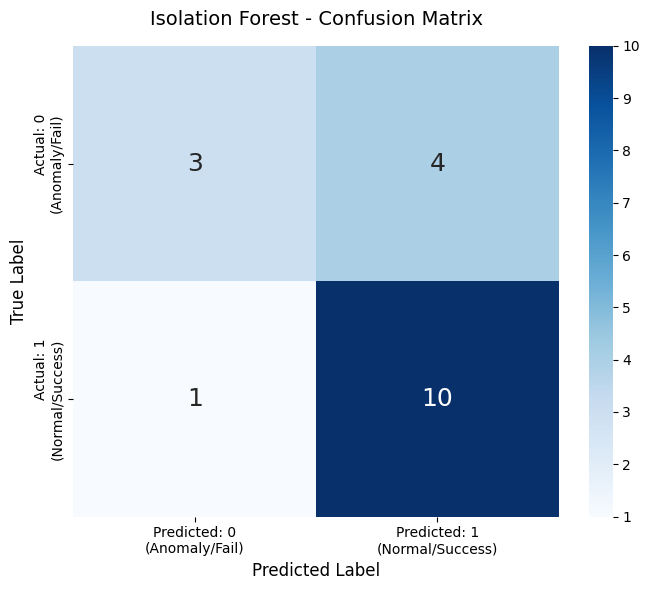

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred_anomaly)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 18},
            xticklabels=['Predicted: 0\n(Anomaly/Fail)', 'Predicted: 1\n(Normal/Success)'],
            yticklabels=['Actual: 0\n(Anomaly/Fail)', 'Actual: 1\n(Normal/Success)'])
plt.title('Isolation Forest - Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

SHAP values 계산 중... (데이터 크기에 따라 시간이 걸릴 수 있습니다)


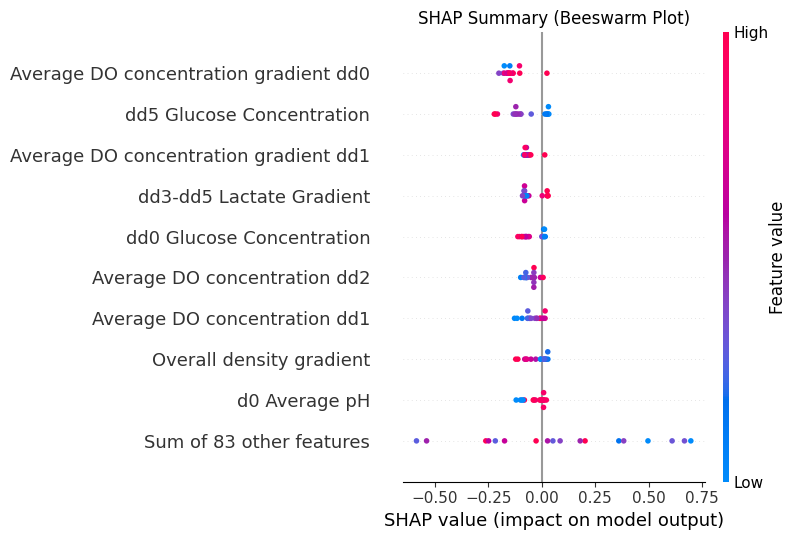

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import shap
import matplotlib.pyplot as plt

# SHAP Value 계산
print("SHAP values 계산 중... (데이터 크기에 따라 시간이 걸릴 수 있습니다)")
explainer = shap.Explainer(iso_forest)
shap_values = explainer(X_test)

# Beeswarm Plot 시각화
plt.style.use('default')
plt.figure()
plt.title("SHAP Summary (Beeswarm Plot)")
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()

# 컬럼 피쳐 중요도 - 컬럼 정제

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import re

X_train = df_train.drop(columns=['Success/Failure', 'dd10 CM Content'], errors='ignore').select_dtypes(include=[np.number])
y_train = np.where(df_train['dd10 CM Content'] >= 70, 1, 0)

# 변수 중요도 산출
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_temp.feature_importances_
})

# 변수명에서 그룹명 추출
def extract_group_name(col_name):
    clean_name = re.sub(r'^(d\d+|dd\d+)\s*-\s*(d\d+|dd\d+)\s*', '', col_name)
    clean_name = re.sub(r'^(d\d+|dd\d+)\s*', '', clean_name)
    clean_name = clean_name.replace('Gradient', '').strip()
    return clean_name

importance_df['Group'] = importance_df['Feature'].apply(extract_group_name)

# 그룹별 최고 중요도 산출
group_importance = importance_df.groupby('Group')['Importance'].max().sort_values(ascending=False)

print("[주제(그룹)별 최고 중요도 순위]")
print(group_importance.head(10))

# 상위 그룹 변수 선택
top_n_groups = group_importance.head(5).index.tolist()
final_selected_features = importance_df[importance_df['Group'].isin(top_n_groups)]['Feature'].tolist()

print(f"\n최종 선택된 변수 개수: {len(final_selected_features)}개")
print(final_selected_features)

X_train_grouped = X_train[final_selected_features]
X_test_grouped = df_test[final_selected_features]

[주제(그룹)별 최고 중요도 순위]
Group
Lactate Concentration                              0.056207
Start Preculture Perfusion [h after inoc] d1-d2    0.052476
Average pH                                         0.041521
Preculture Time [h]                                0.032709
Cell Density                                       0.030940
Aggregate Size                                     0.029698
Average DO concentration gradient dd2              0.024559
Average DO concentration gradient d0               0.023950
Average DO concentration gradient dd3              0.019298
Presence of  IWP2 [h]                              0.016711
Name: Importance, dtype: float64

최종 선택된 변수 개수: 38개
['dd0 Cell Density', 'dd0-dd1 Cell Density Gradient', 'dd1 Cell Density', 'dd1-dd2 Cell Density Gradient', 'dd2 Cell Density', 'dd2-dd3 Cell Density Gradient', 'dd3 Cell Density ', 'dd3-dd5 Cell Density Gradient', 'dd5 Cell Density', 'dd5-dd7 Cell Density Gradient', 'dd7 Cell Density', 'Preculture Time [h]', 'Start Precu

In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import re

# 컬럼명 특수문자 제거
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train_grouped.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_train_grouped.columns]
X_test_grouped.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_test_grouped.columns]

# 결측치 처리
X_train_grouped = X_train_grouped.fillna(X_train_grouped.mean())
X_test_grouped = X_test_grouped.fillna(X_train_grouped.mean())

# SMOTE + XGBoost 파이프라인 구성
smote = SMOTE(k_neighbors=2, random_state=42)
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
pipeline = ImbPipeline(steps=[('smote', smote), ('xgb', xgb_base)])

param_grid = {
    'xgb__max_depth': [2, 3, 4],
    'xgb__n_estimators': [700, 800, 900],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8],
    'xgb__colsample_bytree': [0.6, 0.8]
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearchCV 수행
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall_macro',
    cv=cv_strategy,
    n_jobs=-1
)
grid_search.fit(X_train_grouped, y_train)
best_model = grid_search.best_estimator_

# 임계값 조정 후 예측
y_pred_proba_fail = best_model.predict_proba(X_test_grouped)[:, 0]
custom_threshold = 0.20
y_pred_custom = np.where(y_pred_proba_fail >= custom_threshold, 0, 1)

# 성능 평가
best_params_clean = {k.replace('xgb__', ''): v for k, v in grid_search.best_params_.items()}
print(f"최적 파라미터: {best_params_clean}")
print(f"\n임계값({custom_threshold}) 적용 Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom, zero_division=0))

최적 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 900, 'subsample': 0.6}

임계값(0.2) 적용 Accuracy: 0.5556
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.40      0.29      0.33         7
           1       0.62      0.73      0.67        11

    accuracy                           0.56        18
   macro avg       0.51      0.51      0.50        18
weighted avg       0.53      0.56      0.54        18



In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import LeaveOneOut, cross_val_predict, ParameterGrid
from sklearn.metrics import classification_report, accuracy_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import re

# 컬럼명 특수문자 제거
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train_grouped.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_train_grouped.columns]
X_test_grouped.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_test_grouped.columns]

# LOOCV 파라미터 탐색 범위
param_grid = {
    'xgb__max_depth': [2, 3],
    'xgb__n_estimators': [700, 800, 900],
    'xgb__learning_rate': [0.01],
    'xgb__subsample': [0.8, 0.9],
    'xgb__colsample_bytree': [0.8, 0.9]
}

grid = list(ParameterGrid(param_grid))
loo = LeaveOneOut()

best_score = -1
best_params = None

# LOOCV로 최적 파라미터 탐색
for params in grid:
    xgb_params = {k.replace('xgb__', ''): v for k, v in params.items()}

    smote = SMOTE(k_neighbors=2, random_state=42)
    xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss', **xgb_params)
    pipeline = ImbPipeline(steps=[('smote', smote), ('xgb', xgb_base)])

    y_pred_cv = cross_val_predict(pipeline, X_train_grouped, y_train, cv=loo, n_jobs=-1)
    recall_fail = recall_score(y_train, y_pred_cv, pos_label=0, zero_division=0)

    if recall_fail > best_score:
        best_score = recall_fail
        best_params = xgb_params

print(f"최적 파라미터: {best_params}")
print(f"Train LOOCV 실패(0) 재현율: {best_score:.4f}\n")

# 최적 파라미터로 최종 모델 학습
final_smote = SMOTE(k_neighbors=2, random_state=42)
final_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss', **best_params)
final_pipeline = ImbPipeline(steps=[('smote', final_smote), ('xgb', final_xgb)])
final_pipeline.fit(X_train_grouped, y_train)

# 임계값 조정 후 예측
y_pred_proba_fail = final_pipeline.predict_proba(X_test_grouped)[:, 0]
custom_threshold = 0.35
y_pred_final = np.where(y_pred_proba_fail >= custom_threshold, 0, 1)

# 성능 평가
print(f"최종 Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"--- 최종 Classification Report (Threshold: {custom_threshold}) ---")
print(classification_report(y_test, y_pred_final, zero_division=0))

최적 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 700, 'subsample': 0.8}
Train LOOCV 실패(0) 재현율: 0.5294

최종 Test Accuracy: 0.5556
--- 최종 Classification Report (Threshold: 0.35) ---
              precision    recall  f1-score   support

           0       0.33      0.14      0.20         7
           1       0.60      0.82      0.69        11

    accuracy                           0.56        18
   macro avg       0.47      0.48      0.45        18
weighted avg       0.50      0.56      0.50        18



In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, accuracy_score
import re

# 성공 데이터만으로 Isolation Forest 학습
X_train_success = X_train_grouped[y_train == 1]

iso_forest = IsolationForest(n_estimators=160, contamination=0.19, random_state=42)
iso_forest.fit(X_train_success)

predictions = iso_forest.predict(X_test_grouped)
y_pred_anomaly = np.where(predictions == -1, 0, 1)

# 성능 평가
print(f"최종 Accuracy: {accuracy_score(y_test, y_pred_anomaly):.4f}")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_anomaly, zero_division=0))

최종 Accuracy: 0.7222
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.71      0.91      0.80        11

    accuracy                           0.72        18
   macro avg       0.73      0.67      0.67        18
weighted avg       0.73      0.72      0.70        18



In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler
import re

# 성공 데이터만으로 Isolation Forest 학습
X_train_success = X_train_grouped[y_train == 1]

iso_forest = IsolationForest(n_estimators=160, contamination=0.19, random_state=42)
iso_forest.fit(X_train_success)

# 이상치 점수 추출 및 0~1 스케일링
train_scores = iso_forest.decision_function(X_train_grouped).reshape(-1, 1)
test_scores = iso_forest.decision_function(X_test_grouped).reshape(-1, 1)

scaler = MinMaxScaler()
scaler.fit(train_scores)
scaled_test_scores = scaler.transform(test_scores).flatten()

# 임계값 조정 후 예측
custom_threshold = 0.5
y_pred_anomaly = np.where(scaled_test_scores < custom_threshold, 0, 1)

# 성능 평가
print(f"임계값({custom_threshold}) 적용 Accuracy: {accuracy_score(y_test, y_pred_anomaly):.4f}")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_anomaly, zero_division=0))

임계값(0.5) 적용 Accuracy: 0.6667
--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.14      0.25         7
           1       0.65      1.00      0.79        11

    accuracy                           0.67        18
   macro avg       0.82      0.57      0.52        18
weighted avg       0.78      0.67      0.58        18

